# Honeycomb Tight-Binding Model

Let's setup the problem class using the honeycomb data json.

In [8]:
from acceptor_TI import Problem

data_path = "../../../acceptor_TI/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [9]:
hopping_dict = problem.cell_parser.eigenvalues.nn_hopping.value
hopping_dict["t_ss_sigma"] = -1.4
hopping_dict["t_sp_sigma"] = 1
hopping_dict["t_pp_sigma"] = 1
hopping_dict["t_pp_pi"] = -0.5

In [10]:
location = "edge"
problem.setup(
    N_r = 10,            # size of lattice in real space
    N_k = 300,           # reciprocal space discretization
    location = location  # location of where to calculate eigenvalues
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


## Clebsch-Gordan Coefficients

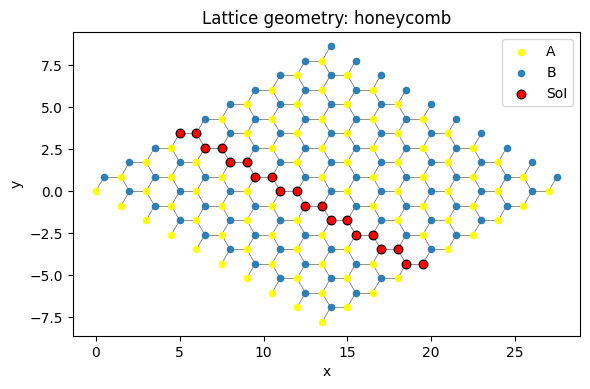

In [11]:
tb = problem.hamiltonian[location]["tight_binding"] 
problem.geometry.plot_lattice(sites_of_interest=tb.sublattice_idxs)
g = problem.geometry

In [12]:
g.T, g.T_norm, g.T_hat


(array([1.5      , 0.8660254]),
 1.7320508075688772,
 array([0.8660254, 0.5      ]))

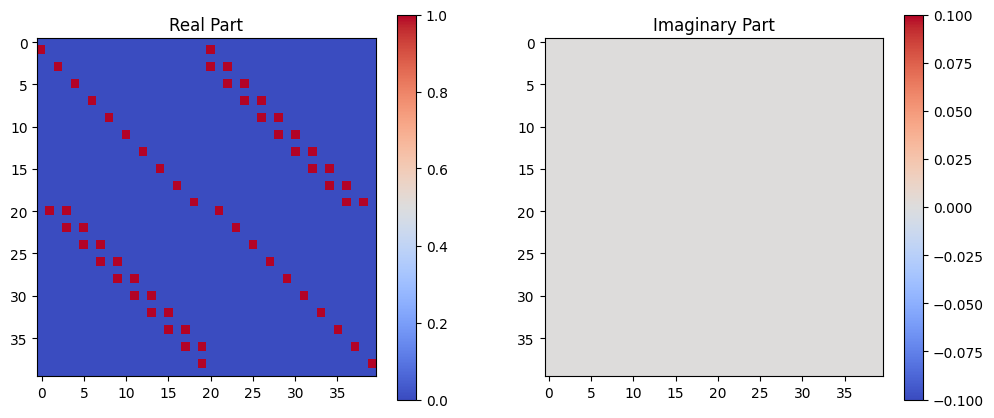

In [13]:
tb._visualise_matrix(tb.sublattice_connectivity)

In [14]:
tb.sublattice_data_dict["A"].keys()
sublattice_A = list(tb.sublattice_data_dict["A"].keys())[0]

## Coupled Angular Momentum States

In [20]:
sublattice_B = tb.sublattice_data_dict["A"][sublattice_A]["neighbour_idxs"][0]
# tb.sublattice_data_dict["A"][sublattice_A]['hopping_dict'][sublattice_B]

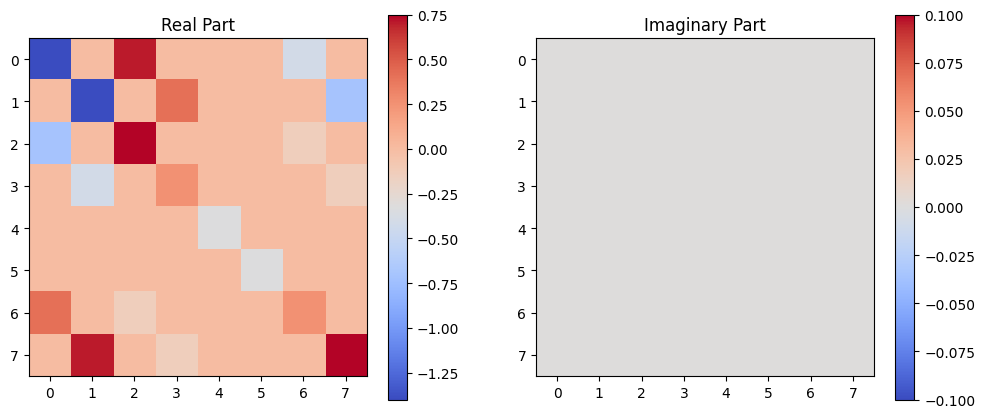

In [16]:

tb._visualise_matrix(tb.sublattice_data_dict["A"][sublattice_A]['hopping_dict'][sublattice_B])

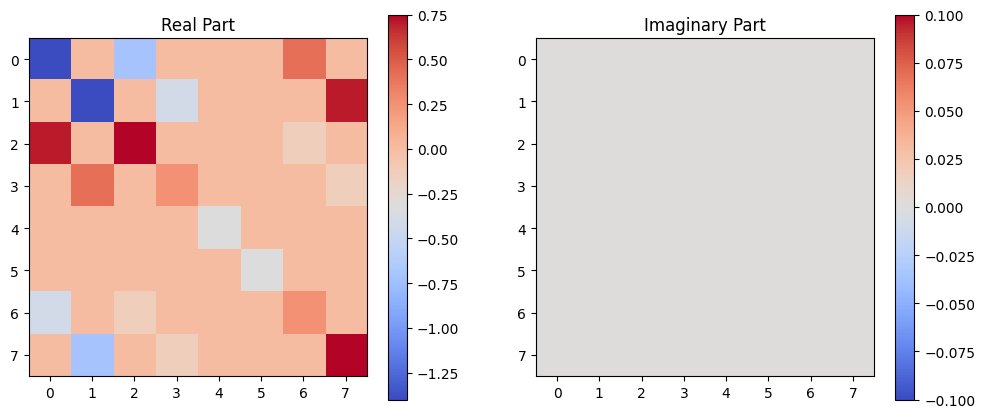

In [17]:

tb._visualise_matrix(tb.sublattice_data_dict["B"][sublattice_B]['hopping_dict'][sublattice_A])

In [18]:
problem.run(
    acceptor=False,
    H_type="reciprocal_space"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done.


In [32]:
E_list = []

In [36]:
import numpy as np


# for k in g.k_edge:
idx =  140
H_k = tb.H.copy()
k = g.k_edge[idx]
N_projections = tb.n_orbitals * tb.n_spins
idx_map = {idx: pos for pos, idx in enumerate(tb.unique_idxs)}
for sublattice_dict in tb.sublattice_data_dict.values():
    for idx_i, site_dict in sublattice_dict.items():
        if idx_i not in idx_map:
                    continue
        i = idx_map[idx_i]
        row_slice = slice(i * N_projections, (i + 1) * N_projections)
        for idx_j in site_dict["neighbour_idxs"]:
            if (idx_j not in idx_map) or (idx_j in tb.sublattice_idxs):
                continue
            j = idx_map[idx_j]
            col_slice = slice(j * N_projections, (j + 1) * N_projections)
            m_ij = site_dict["dm_dict"][idx_j]
            phase = np.exp(1j * k * m_ij * g.T_norm)
            print(idx_i, idx_j, phase)
            H_k[row_slice, col_slice] *= phase
E_k, U = np.linalg.eigh(H_k)
E_list.append(E_k)

98 99 (0.9950224690546545+0.09965082075115642j)
96 97 (0.9950224690546545+0.09965082075115642j)
94 95 (0.9950224690546545+0.09965082075115642j)
92 93 (0.9950224690546545+0.09965082075115642j)
90 91 (0.9950224690546545+0.09965082075115642j)
88 89 (0.9950224690546545+0.09965082075115642j)
86 87 (0.9950224690546545+0.09965082075115642j)
84 85 (0.9950224690546545+0.09965082075115643j)
82 83 (0.9950224690546545+0.09965082075115642j)
80 81 (0.9950224690546545+0.09965082075115642j)
79 78 (0.9950224690546545-0.09965082075115642j)
77 76 (0.9950224690546545-0.09965082075115642j)
75 74 (0.9950224690546545-0.09965082075115642j)
73 72 (0.9950224690546545-0.09965082075115642j)
71 70 (0.9950224690546545-0.09965082075115642j)
69 68 (0.9950224690546545-0.09965082075115642j)
67 66 (0.9950224690546545-0.09965082075115642j)
65 64 (0.9950224690546545-0.09965082075115642j)
63 62 (0.9950224690546545-0.09965082075115642j)
61 60 (0.9950224690546545-0.09965082075115642j)


300